# 00 -- EDA sanity check (MVP1, Step 0)

Run this before writing any code that trains. Catches: axis-order bugs in
polygon->mask rasterization, off-by-one errors, whether the sun disk fills the
frame or sits inside a black border, and confirms the train vs. test filename
schemes (needed for `filament_id` construction in `src/submission.py`).


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

DATA_JSON = Path("../data/raw/MAGFiLO_1.0_Kaggle_2026/train/MAGFiLO_1.0_Annotations_kaggle2026_train.json")
TRAIN_IMG_DIR = Path("../data/raw/MAGFiLO_1.0_Kaggle_2026/train/train_images")
TEST_IMG_DIR = Path("../data/raw/MAGFiLO_1.0_Kaggle_2026/test/test_images")

coco = COCO(str(DATA_JSON))
print(f"{len(coco.imgs)} image entries, {len(coco.anns)} annotations, categories={[c['name'] for c in coco.cats.values()]}")


loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
1154 image entries, 8199 annotations, categories=['Left', 'Right', 'Unidentifiable', 'Ambiguous']


## Image size + disk framing sanity check

In [2]:
sizes = {(info["height"], info["width"]) for info in coco.imgs.values()}
print("distinct (height, width) values across all images:", sizes)
assert sizes == {(2048, 2048)}, "expected every image to be exactly 2048x2048"
print("OK: every image is 2048x2048.")


distinct (height, width) values across all images: {(2048, 2048)}
OK: every image is 2048x2048.


## Polygon -> mask overlay sanity check\n\n`coco.annToMask` wraps `frPyObjects` + `decode` correctly for these single-polygon, `iscrowd=0` annotations -- this is the load-bearing call `src/dataset.py` relies on instead of hand-rolling polygon rasterization. If axis order were wrong, the masks below would be transposed/mirrored relative to the visible dark filament threads.

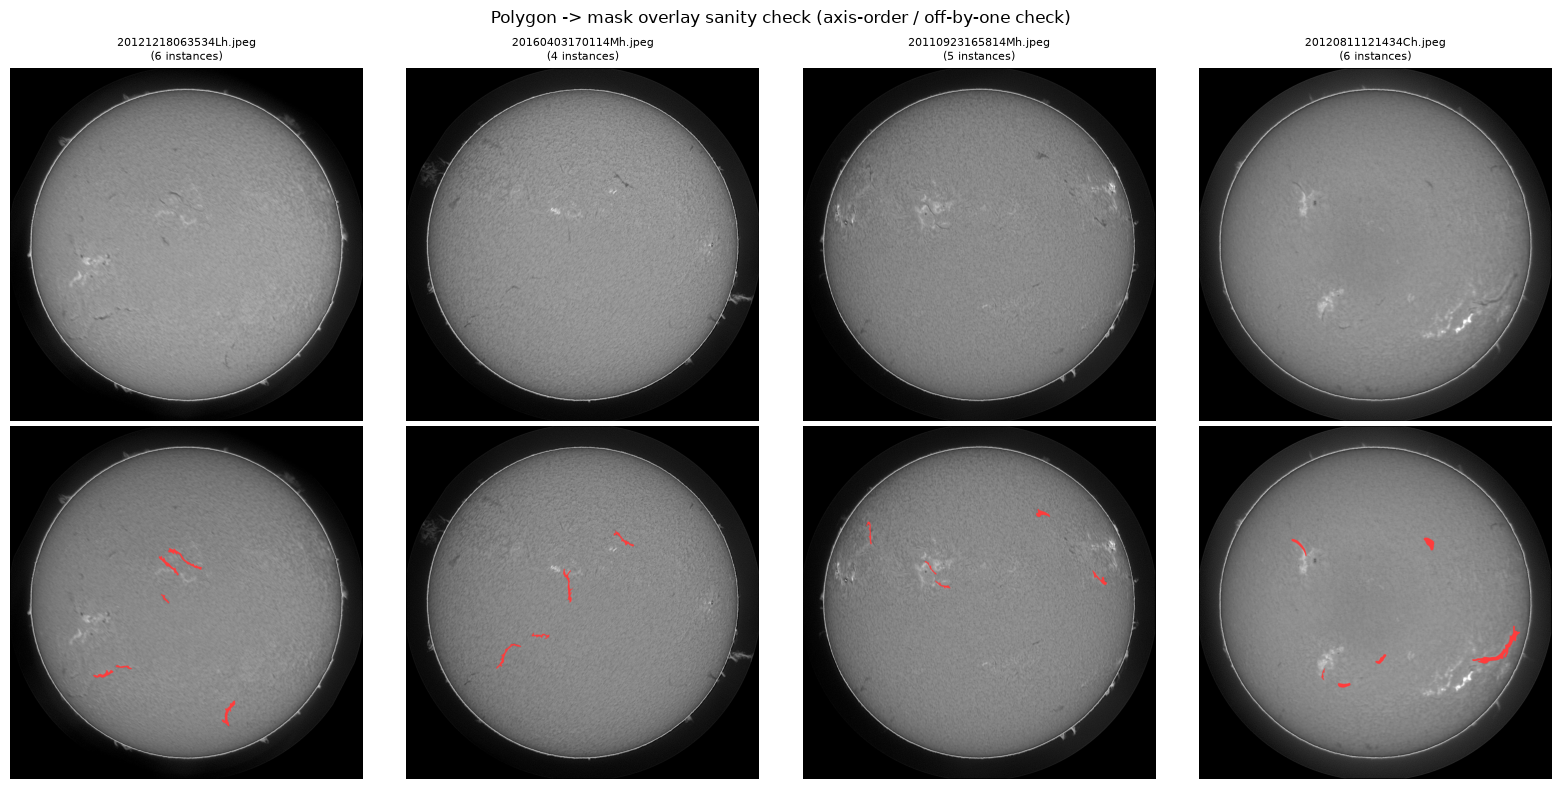

In [3]:
image_ids = list(coco.imgs.keys())
rng = np.random.default_rng(0)
sample_ids = rng.choice(image_ids, size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, image_id in enumerate(sample_ids):
    info = coco.imgs[image_id]
    img = cv2.imread(str(TRAIN_IMG_DIR / info["file_name"]), cv2.IMREAD_GRAYSCALE)
    ann_ids = coco.getAnnIds(imgIds=[image_id])
    anns = coco.loadAnns(ann_ids)
    mask = np.zeros(img.shape, dtype=np.uint8)
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"{info['file_name']}\n({len(anns)} instances)", fontsize=8)
    axes[0, col].axis("off")

    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    overlay[mask > 0] = [255, 60, 60]
    axes[1, col].imshow(overlay)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("raw", fontsize=10)
axes[1, 0].set_ylabel("mask overlay", fontsize=10)
fig.suptitle("Polygon -> mask overlay sanity check (axis-order / off-by-one check)")
fig.tight_layout()
plt.show()


## Critical gotcha found here: pycocotools' `getAnnIds` silently breaks on string `image_id`s

`images[].id` in this dataset is a **string** (e.g. `"040301-20140609195854Bh"`), not
pycocotools' usual int. `pycocotools.coco._isArrayLike` treats a bare string as
already "array-like" (a string has both `__iter__` and `__len__`), so
`coco.getAnnIds(imgIds=image_id)` does **not** wrap it in a list -- it iterates the
string *character by character* and looks up single characters in `imgToAnns`,
which never match, silently returning `[]` for every single image. This is exactly
the kind of silent, only-surfaces-later bug this notebook exists to catch before it
corrupts a loss computation.

**Fix, applied everywhere in `src/`**: always pass `imgIds=[image_id]` (wrapped in a
list), never a bare string.


In [4]:
sample_iid = image_ids[0]
print("BUGGY  (bare string) ->", len(coco.getAnnIds(imgIds=sample_iid)), "annotations")
print("FIXED  (wrapped list) ->", len(coco.getAnnIds(imgIds=[sample_iid])), "annotations")


BUGGY  (bare string) -> 0 annotations
FIXED  (wrapped list) -> 12 annotations


## Instances-per-image distribution

instances/image: min=1 max=26 mean=7.10 median=7.0
images with zero annotations (valid negatives, keep them): 0


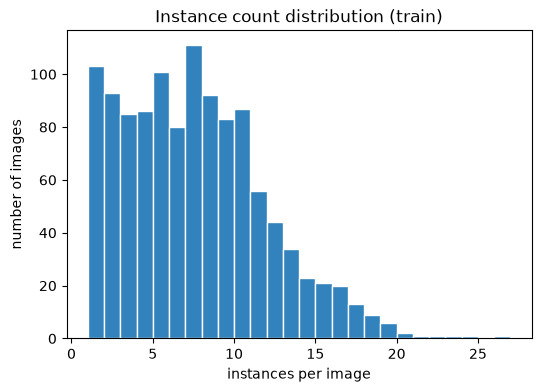

In [5]:
counts = [len(coco.getAnnIds(imgIds=[iid])) for iid in image_ids]
counts = np.array(counts)
print(f"instances/image: min={counts.min()} max={counts.max()} mean={counts.mean():.2f} median={np.median(counts):.1f}")
print(f"images with zero annotations (valid negatives, keep them): {(counts == 0).sum()}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(counts, bins=range(counts.min(), counts.max() + 2), color="#3182bd", edgecolor="white")
ax.set_xlabel("instances per image")
ax.set_ylabel("number of images")
ax.set_title("Instance count distribution (train)")
plt.show()


## Filament area distribution\n\nMany filaments are small/thin -- relevant for choosing the loss (Dice helps with class imbalance) and the postprocessing `min_area_px` speckle-filter threshold.

area (px): min=9 median=1228 max=37739


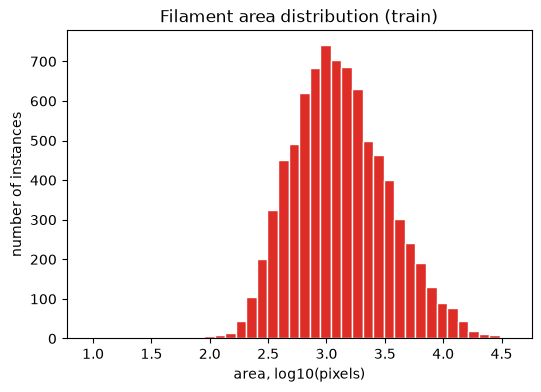

In [6]:
areas = np.array([ann["area"] for ann in coco.anns.values()])
print(f"area (px): min={areas.min():.0f} median={np.median(areas):.0f} max={areas.max():.0f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(areas), bins=40, color="#de2d26", edgecolor="white")
ax.set_xlabel("area, log10(pixels)")
ax.set_ylabel("number of instances")
ax.set_title("Filament area distribution (train)")
plt.show()


## Train vs. test filename scheme\n\nTraining `image_id`s carry an annotator-batch prefix (`010401-20160920230134Lh`). Confirm test image filenames do **not** carry that prefix, since `src/infer.py`/`src/submission.py` build `filament_id = f'{file_stem}_{k}'` directly from the test filename stem.

In [7]:
sample_train_ids = list(coco.imgs.keys())[:5]
print("sample train image_ids:", sample_train_ids)
print("sample train file_names:", [coco.imgs[i]["file_name"] for i in sample_train_ids])

test_files = sorted(TEST_IMG_DIR.glob("*.jpeg"))[:5]
print("sample test filenames:", [p.name for p in test_files])
print(f"total test images: {len(list(TEST_IMG_DIR.glob('*.jpeg')))}")


sample train image_ids: ['040301-20140609195854Bh', '050103-20111116063134Lh', '050102-20111116063134Lh', '050101-20111116063134Lh', '030101-20130725122934Ch']
sample train file_names: ['20140609195854Bh.jpeg', '20111116063134Lh.jpeg', '20111116063134Lh.jpeg', '20111116063134Lh.jpeg', '20130725122934Ch.jpeg']
sample test filenames: ['20110120105534Ch.jpeg', '20110130110334Ch.jpeg', '20110214175414Mh.jpeg', '20110329082654Uh.jpeg', '20110408083214Th.jpeg']
total test images: 180


## Conclusions

- Image size is uniformly 2048x2048 -- no per-image resize-factor bookkeeping needed
  beyond what `src/dataset.py`/`src/infer.py` already do.
- The sun disk sits inside a black border (visible above) -- background is not
  uniformly informative; `src/postprocess.py`'s connected-components step naturally
  ignores it since the model should learn to predict all-zero there.
- Polygon -> mask overlays land exactly on the visible dark filament threads --
  `coco.annToMask` axis order is correct, no transpose/mirror bug.
- Filament areas span several orders of magnitude (many small/thin instances) --
  confirms Dice-loss and a `min_area_px` postprocessing filter are both warranted.
- Test filenames have no annotator-batch prefix, confirming `filament_id` can be
  built directly from the test filename stem.
- **`pycocotools.coco.getAnnIds` silently returns zero annotations when passed a
  bare string `image_id`** (see above) -- fixed everywhere in `src/` by always
  wrapping in a list. Worth remembering if any new code ever calls a pycocotools
  `COCO` method with a single id instead of a list.
